# Credit Risk Model — Full Evaluation

PD modeling with Logistic Regression & XGBoost, regulatory metrics, and stress testing.

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from xgboost import XGBClassifier

ROOT = Path.cwd()
if not (ROOT / 'ML').exists():
    ROOT = ROOT.parent.parent if ROOT.name == 'notebooks' else ROOT.parent
sys.path.insert(0, str(ROOT))

from ML.features.engineering import clean_raw_data, engineer_features, prepare_training_frame
from ML.features.preprocessing import fit_preprocessor
from ML.utils import compute_metrics
from ML.risk_scoring import enrich_prediction, compute_ecl
from backend.data.macro_loader import load_macro_scenarios
from backend.stress.scenarios import apply_pd_shock

DATA_PATH = ROOT / 'data' / 'credit_risk_dataset_new.csv'
print('Project root:', ROOT)

Project root: c:\Users\JOY\Downloads\CR, POD & ST


## 1. Exploratory Data Analysis

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Default rate:', f"{df['loan_status'].mean():.2%}")
df.head()

Shape: (32581, 12)
Default rate: 21.82%


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
print('Missing values:\n', df.isnull().sum())
print('Age > 100:', (df['person_age'] > 100).sum())
print('Emp length > 50:', (df['person_emp_length'] > 50).sum())
print('Max age:', df['person_age'].max())

Missing values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Age > 100: 5
Emp length > 50: 2
Max age: 144


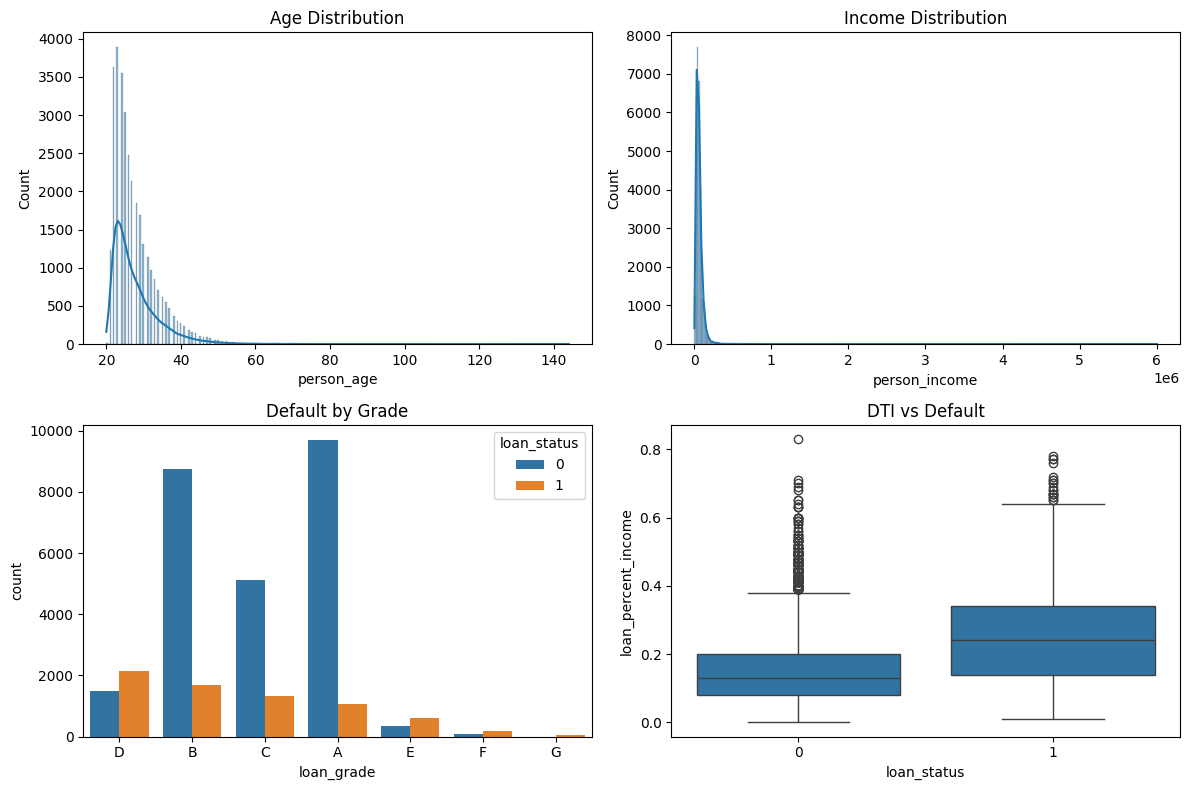

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['person_age'], kde=True, ax=axes[0,0]); axes[0,0].set_title('Age Distribution')
sns.histplot(df['person_income'], kde=True, ax=axes[0,1]); axes[0,1].set_title('Income Distribution')
sns.countplot(data=df, x='loan_grade', hue='loan_status', ax=axes[1,0]); axes[1,0].set_title('Default by Grade')
sns.boxplot(data=df, x='loan_status', y='loan_percent_income', ax=axes[1,1]); axes[1,1].set_title('DTI vs Default')
plt.tight_layout(); plt.show()

## 2. Data Cleaning & Feature Engineering

In [6]:
df_clean = clean_raw_data(df)
X, y, feature_cols = prepare_training_frame(df_clean)
print('Features:', feature_cols)
print('Target distribution:\n', y.value_counts(normalize=True))

Features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'log_person_income', 'dti_ratio', 'loan_grade_ord', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'age_bucket', 'income_bucket']
Target distribution:
 loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


## 3. Train/Test Split & Preprocessing

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = fit_preprocessor(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)
pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
print('Train:', len(X_train), 'Test:', len(X_test))

Train: 26064 Test: 6517


## 4. Model Training — Logistic Regression & XGBoost

In [8]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_t, y_train)
lr_prob = lr.predict_proba(X_test_t)[:, 1]

xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, scale_pos_weight=pos_weight,
                    eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train_t, y_train)
xgb_prob = xgb.predict_proba(X_test_t)[:, 1]
print('Models trained.')

Models trained.


## 5. Model Metrics

In [9]:
lr_metrics = compute_metrics(y_test.values, lr_prob)
xgb_metrics = compute_metrics(y_test.values, xgb_prob)
metrics_df = pd.DataFrame([lr_metrics, xgb_metrics], index=['Logistic Regression', 'XGBoost'])
metrics_df

,roc_auc,f1,precision,recall,accuracy,ks,gini
Logistic Regression,0.877341,0.651082,0.552129,0.793249,0.814485,0.628204,0.754683
XGBoost,0.951125,0.812567,0.825236,0.800281,0.919441,0.757969,0.902250


## 6. Confusion Matrix

In [10]:
for name, prob in [('LR', lr_prob), ('XGB', xgb_prob)]:
    cm = confusion_matrix(y_test, (prob >= 0.5).astype(int))
    print(f'\n{name} Confusion Matrix:')
    print(cm)
    print(classification_report(y_test, (prob >= 0.5).astype(int)))


LR Confusion Matrix:
[[4180  915]
 [ 294 1128]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.79      0.65      1422

    accuracy                           0.81      6517
   macro avg       0.74      0.81      0.76      6517
weighted avg       0.85      0.81      0.83      6517


XGB Confusion Matrix:
[[4854  241]
 [ 284 1138]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5095
           1       0.83      0.80      0.81      1422

    accuracy                           0.92      6517
   macro avg       0.88      0.88      0.88      6517
weighted avg       0.92      0.92      0.92      6517



## 7. ROC Curve

In [11]:
fig = go.Figure()
for name, prob, color in [('LR', lr_prob, 'blue'), ('XGB', xgb_prob, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{name} (AUC={auc(fpr,tpr):.3f})', line=dict(color=color)))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
fig.update_layout(title='ROC Curves', xaxis_title='FPR', yaxis_title='TPR')
fig.show()

## 8. Feature Importance

In [13]:
print("Number of feature importances:", len(xgb.feature_importances_))
print("Number of columns in feature_cols:", len(feature_cols))

Number of feature importances: 38
Number of columns in feature_cols: 16


In [17]:
import pandas as pd
import plotly.express as px

# 1. Grab the feature names stored inside the model
feature_names = xgb.get_booster().feature_names

# 2. Create the series and grab the top 10 features
importance = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=True).tail(10)

# 3. Plot with explicit x and y axis labels
fig = px.bar(
    x=importance.values, 
    y=importance.index, 
    orientation='h', 
    title='XGBoost Feature Importance',
    labels={'x': 'Relative Importance (Gini/Gain)', 'y': 'Features'} # Adds clear labels
)

# Optional: Ensure layout looks clean and tight
fig.update_layout(xaxis_title="Importance Score", yaxis_title="Features")

fig.show()

## 9. Lift Chart

In [20]:
def lift_chart(y_true, y_prob, n_bins=10):
    data = pd.DataFrame({'y': y_true, 'prob': y_prob})
    data['bin'] = pd.qcut(data['prob'], n_bins, duplicates='drop')
    
    lift = data.groupby('bin', observed=True)['y'].agg(['mean', 'count'])
    lift['lift'] = lift['mean'] / data['y'].mean()
    
    lift = lift.reset_index()
    
    # FIX: Convert Interval data type to String so Plotly can parse it as categories
    lift['bin'] = lift['bin'].astype(str)
    
    return lift

# Calculate lift
lift = lift_chart(y_test.values, xgb_prob)

# Plot with explicit labels
fig = px.bar(
    lift, 
    x='bin', 
    y='lift', 
    title='Lift Chart (XGBoost)', 
    labels={'bin': 'Probability Deciles/Bins', 'lift': 'Lift'}
)

fig.show()

## 10. Stress Test Examples

In [21]:
scenarios = load_macro_scenarios()
for name, s in scenarios.items():
    print(f"{name}: portfolio PD multiplier = {s.portfolio_pd_multiplier:.2f}")

sample = df_clean.sample(200, random_state=42)
sample_probs = xgb.predict_proba(preprocessor.transform(prepare_training_frame(sample)[0]))[:, 1]

stress_rows = []
for name, scenario in scenarios.items():
    shocked = apply_pd_shock(sample_probs, scenario)
    total_ecl = 0.0
    for p, ead in zip(shocked, sample['loan_amnt']):
        stage = enrich_prediction(float(p), float(ead))['ifrs9_stage']
        total_ecl += compute_ecl(float(p), float(ead), stage)
    stress_rows.append({'scenario': name, 'avg_pd': float(shocked.mean()), 'total_ecl': total_ecl})

pd.DataFrame(stress_rows)

Normal: portfolio PD multiplier = 1.00
Boom: portfolio PD multiplier = 0.86
Recession: portfolio PD multiplier = 1.30


,scenario,avg_pd,total_ecl
0,Normal,0.295959,324169.041328
1,Boom,0.255265,298987.741585
2,Recession,0.340162,375002.530261


In [22]:
stress_df = pd.DataFrame(stress_rows)
fig = px.bar(stress_df, x='scenario', y=['avg_pd', 'total_ecl'], barmode='group', title='Stress Test Comparison')
fig.show()